 I installed and imported all necessary libraries. I used yfinance to fetch Tesla stock data, pandas for data handling, matplotlib and seaborn for visualization, and scikit-learn for building and evaluating the regression model.

In [1]:
!pip install yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
sns.set(style="whitegrid")

In this step, I used the yfinance library to fetch historical stock data for Tesla from 2018 to 2024. The dataset includes features like Open, High, Low, Close, and Volume, which are essential for predicting future stock prices

In [2]:
ticker = "TSLA"
df = yf.download(ticker, start="2018-01-01", end="2024-12-31")
df.head()

/tmp/ipykernel_3315/2891924735.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2018-01-02,21.368668,21.474001,20.733334,20.799999,65283000
2018-01-03,21.150000,21.683332,21.036667,21.400000,67822500
2018-01-04,20.974667,21.236668,20.378668,20.858000,149194500
2018-01-05,21.105333,21.149332,20.799999,21.108000,68868000
2018-01-08,22.427334,22.468000,21.033333,21.066668,147891000


I inspected the dataset to understand its structure, including shape, column names, and time ordering. The dataset consists of time series stock data where each row represents a trading day, and features include Open, High, Low, Close, and Volume.

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns in dataset:")
print(df.columns)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

Shape of dataset: (1760, 5)

Columns in dataset:
MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

First 5 rows:
Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2018-01-02  21.368668  21.474001  20.733334  20.799999   65283000
2018-01-03  21.150000  21.683332  21.036667  21.400000   67822500
2018-01-04  20.974667  21.236668  20.378668  20.858000  149194500
2018-01-05  21.105333  21.149332  20.799999  21.108000   68868000
2018-01-08  22.427334  22.468000  21.033333  21.066668  147891000

Last 5 rows:
Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                     

I used info() to check data types and missing values, and describe() to analyze statistical properties like mean, range, and volatility of stock prices. The dataset is clean and suitable for regression modeling

In [4]:
print("Dataset Info:\n")
df.info()
print("\nStatistical Summary:\n")
print(df.describe())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1760 entries, 2018-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1760 non-null   float64
 1   (High, TSLA)    1760 non-null   float64
 2   (Low, TSLA)     1760 non-null   float64
 3   (Open, TSLA)    1760 non-null   float64
 4   (Volume, TSLA)  1760 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 82.5 KB

Statistical Summary:

Price         Close         High          Low         Open        Volume
Ticker         TSLA         TSLA         TSLA         TSLA          TSLA
count   1760.000000  1760.000000  1760.000000  1760.000000  1.760000e+03
mean     157.952966   161.508081   154.217363   157.972523  1.277805e+08
std      112.312011   114.900689   109.635012   112.399517  7.961145e+07
min       11.931333    12.445333    11.799333    12.073333  2.940180e+07
25%       23.173834    23.511667  

I created a target variable by shifting the closing price column by one step to represent the next day’s closing price. This allowed me to convert the time-series data into a supervised learning problem where features like Open, High, Low, and Volume are used to predict future prices

In [5]:
df['Target'] = df['Close'].shift(-1)
df = df.dropna()
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']
df.head()

Price,Close,High,Low,Open,Volume,Target
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2018-01-02,21.368668,21.474001,20.733334,20.799999,65283000,21.150000
2018-01-03,21.150000,21.683332,21.036667,21.400000,67822500,20.974667
2018-01-04,20.974667,21.236668,20.378668,20.858000,149194500,21.105333
2018-01-05,21.105333,21.149332,20.799999,21.108000,68868000,22.427334
2018-01-08,22.427334,22.468000,21.033333,21.066668,147891000,22.246000


Since the dataset is time series, I avoided random splitting and instead used a sequential split where the first 80% of data was used for training and the remaining 20% for testing. This ensures that the model is trained on past data and tested on future data, maintaining real-world consistency

In [6]:
split_index = int(len(X) * 0.8)
X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1407, 4)
Testing set size: (352, 4)


I used a Linear Regression model to learn the relationship between stock features such as Open, High, Low, and Volume with the next day’s closing price. The model was trained using historical Tesla stock data

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training completed!")

Model training completed!


I evaluated the model using MAE, MSE, and RMSE. These metrics measure the difference between predicted and actual closing prices. RMSE is particularly useful as it provides error in the same unit as stock price.”

The model achieved an RMSE of approximately 9.46, which means predictions are off by around $9 on average. Considering the volatility of stock prices, this is a reasonable result for a basic Linear Regression model.

However, more advanced models like Random Forest or LSTM could potentially improve prediction accuracy

In [8]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Model Evaluation:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Model Evaluation:
Mean Absolute Error (MAE): 6.593772258028215
Mean Squared Error (MSE): 89.51361310017536
Root Mean Squared Error (RMSE): 9.461163411556496


The plot compares actual and predicted Tesla closing prices. The model captures the general trend of stock movement, although some deviations exist due to market volatility and the simplicity of the Linear Regression model
This approach demonstrates a basic regression pipeline. However, stock prediction can be improved using advanced models like Random Forest, Gradient Boosting, or LSTM for better temporal pattern learning.”

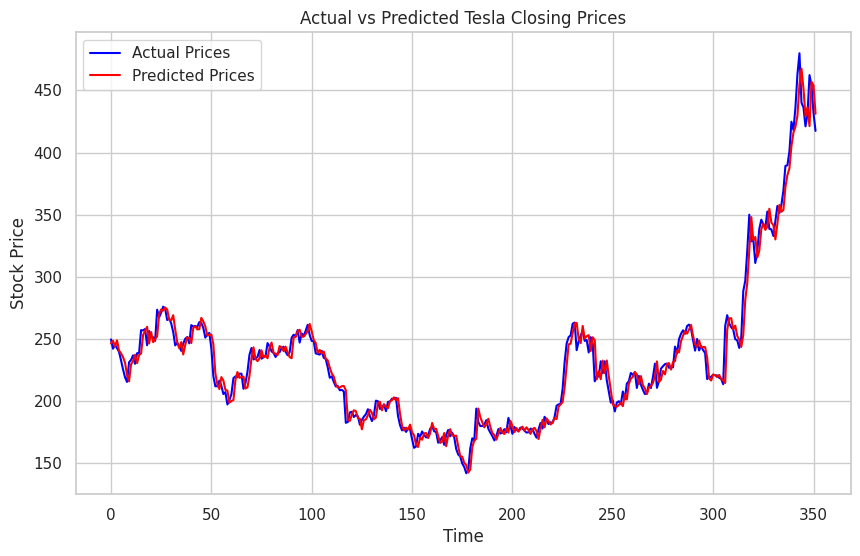

In [9]:

plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual Prices", color="blue")
plt.plot(y_pred, label="Predicted Prices", color="red")
plt.title("Actual vs Predicted Tesla Closing Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

“I performed inference by taking the latest stock features—Open, High, Low, and Volume—from the dataset and passing them to the trained model after reshaping the input. The model then predicted the next day’s closing price based on patterns learned from historical data, simulating real-world stock forecasting

In [10]:
latest_data = df[['Open', 'High', 'Low', 'Volume']].iloc[-1]
latest_data = latest_data.values.reshape(1, -1)
next_day_prediction = model.predict(latest_data)
print("Predicted Next Day Closing Price:", next_day_prediction[0])

Predicted Next Day Closing Price: 431.1645459364756


next

now turning to random forest


preparing and training the random forest dataset
Using RandomForestRegressor
It builds multiple decision trees and combines them
More powerful than Linear Regression
Can capture non-linear relationships

In [11]:

from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest model trained!")

Random Forest model trained!


Predictions and evaluation of random forest

In [12]:
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
print("Random Forest Performance:")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)

Random Forest Performance:
MAE: 8.193330137079412
MSE: 160.69184499651004
RMSE: 12.676428716184619


Visual Comparison

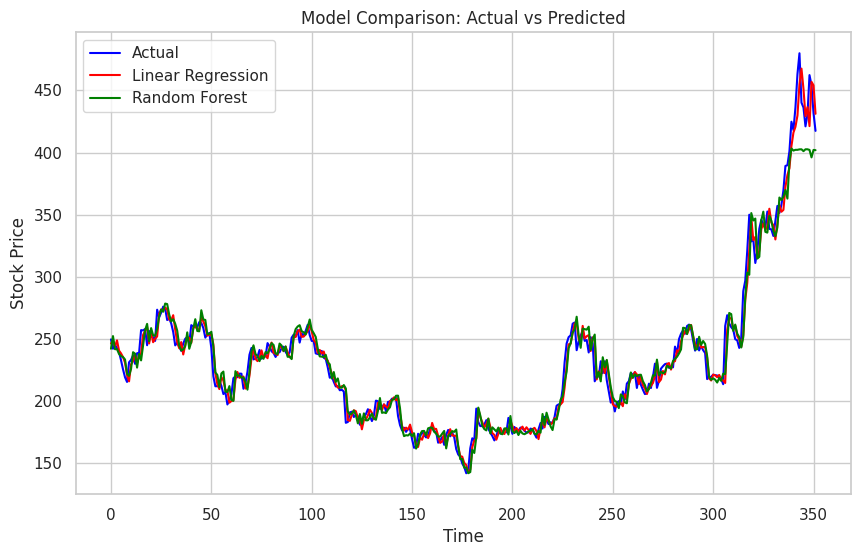

In [13]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual", color="blue")
plt.plot(y_pred, label="Linear Regression", color="red")
plt.plot(rf_pred, label="Random Forest", color="green")
plt.title("Model Comparison: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [14]:
print("Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression RMSE: 9.461163411556496
Random Forest RMSE: 12.676428716184619


comparison understanding between Linear Regression vs Random forest :

I compared Linear Regression with Random Forest Regression for stock price prediction.
Based on the evaluation results the Linear Regression performed better because it achieved a lower RMSE (9.46) compared to Random Forest (12.68), meaning its predictions were closer to the actual values
Although Random Forest is generally better at capturing non linear relationships in data so in this particular dataset it did not perform well and showed higher error, especially around peak values.
In contrast the Linear Regression followed the overall trend more accurately and produced more reliable predictions.
Therefore the Linear Regression is the more suitable model

saving the both mdels

In [16]:
import joblib
joblib.dump(model, "linear_regression_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
print("Models saved successfully!")

Models saved successfully!


In [17]:
joblib.dump(model, "/content/drive/MyDrive/linear_regression_model.pkl")
joblib.dump(rf_model, "/content/drive/MyDrive/random_forest_model.pkl")

['/content/drive/MyDrive/random_forest_model.pkl']

For later reloading the model,  run following cell

In [ ]:
loaded_model = joblib.load("linear_regression_model.pkl")
loaded_model = joblib.load("random_forest_model.pkl")
loaded_model.predict(X_test[:1])